# Part II · Limitation L1 — Lagged Exposure
**Task 8** | *Worksheet §Part II, Limitation L1 (25 min)*

## The problem: simultaneity

The original exposure indicator is
$$E_k(t) = \mathbf{1}[m(k,t) > 0]$$
where $m(k,t)$ counts neighbours **jumping at the same frame $t$** as the focal cell is observed.  
The future self-jump window is $(t, t+W]$.

**Issue:** the neighbour's jump and the focal cell's future window are anchored to the same frame.  
There is no guarantee of temporal precedence — both cells could be responding
to the same upstream stimulus simultaneously.

**Fix:** use a **lagged exposure**
$$E_k^{(\tau)}(t) = \mathbf{1}[m(k,\, t - \tau) > 0]$$
For $\tau \geq 1$ the neighbour's jump *strictly precedes* the focal cell's look-ahead window,
providing genuine temporal precedence.

If ERK truly propagates from neighbour to focal cell, we expect $\mathrm{RR}^{(\tau)}$
to peak at a small lag $\tau^*$ and decay toward 1 at large $\tau$.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..').resolve()
OUTPUT_ROOT  = PROJECT_ROOT / 'analysis_outputs'

# Load the node table produced in Block 1 (exp 1, site 1, ERK)
NODES_PATH = OUTPUT_ROOT / 'exp_1_site_1_ERKKTR_ratio' / 'nodes.csv.gz'
nodes = pd.read_csv(NODES_PATH)
print(f'Loaded {len(nodes):,} nodes from {NODES_PATH.name}')
nodes.head(3)

Loaded 356,632 nodes from nodes.csv.gz


,node_id,Exp_ID,Image_Metadata_Site,track_id,Image_Metadata_T,time_h,objNuclei_Location_Center_X,objNuclei_Location_Center_Y,Nuclear_size,ERKKTR_ratio,FoxO3A_ratio,signal_value,signal_delta,jump_event,neighbor_count,neighbor_jump_count,neighbor_jump_now,neighbor_mean_signal,future_self_jump
0,0,1,1,1,0,0.000000,932.211,875.248,303.0,0.704407,1.33383,0.704407,NaN,False,22,0,False,0.927543,True
1,1,1,1,1,1,0.083333,932.150,874.174,333.0,0.848242,1.33791,0.848242,0.143835,True,22,7,True,0.963904,True
2,2,1,1,1,2,0.166667,932.376,873.787,314.0,1.059170,1.37627,1.059170,0.210928,True,22,5,True,1.004497,True


---
## Worked toy example — why $\tau=0$ is ambiguous

Consider a single track where the neighbour jumps at frame $t$ and the focal cell jumps at $t+1$.
At $\tau=0$: the focal cell is labelled *exposed* ($E_k(t)=1$) and *future-jumping* ($\mathcal{F}_k(t)=1$ for $W \geq 1$).  
At $\tau=1$: the lagged exposure at $t+1$ looks at $m(k, t)>0$ — still 1, but now the neighbour's jump
**precedes** the focal cell's future window $(t+1, t+1+W]$. The causal arrow is correctly oriented.

In [3]:
# Reconstruct a minimal example from one track
sample_track = nodes.loc[nodes['track_id'] == nodes['track_id'].value_counts().index[0]]
sample_track = sample_track.sort_values('Image_Metadata_T').head(10)
print(sample_track[['Image_Metadata_T', 'signal_value', 'jump_event',
                     'neighbor_jump_now', 'future_self_jump']].to_string(index=False))

 Image_Metadata_T  signal_value  jump_event  neighbor_jump_now  future_self_jump
                0      0.704407       False              False              True
                1      0.848242        True               True              True
                2      1.059170        True               True              True
                3      1.188000        True               True             False
                4      1.205540       False               True             False
                5      1.208040       False               True             False
                6      1.165190       False               True             False
                7      1.094710       False               True             False
                8      1.001350       False               True             False
                9      0.931540       False               True             False


---
## Step 1 — Construct lagged exposure columns

Within each track, shift `neighbor_jump_now` forward by $\tau$ frames.
This means: "did any of my neighbours jump $\tau$ frames ago?"

In [4]:
nodes = nodes.sort_values(['track_id', 'Image_Metadata_T']).reset_index(drop=True)

MAX_LAG = 6

for tau in range(1, MAX_LAG + 1):
    # shift(tau) within each track: row at position i gets the value from i-tau
    # i.e. "neighbour jump status tau frames ago"
    nodes[f'lagged_exposure_{tau}'] = (
        nodes.groupby('track_id')['neighbor_jump_now']
             .shift(tau)
             .fillna(False)
             .astype(bool)
    )

print('Lagged exposure columns created:')
print([c for c in nodes.columns if 'lagged' in c])

C:\Users\gozma\AppData\Local\Temp\ipykernel_22944\78900910.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
C:\Users\gozma\AppData\Local\Temp\ipykernel_22944\78900910.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
C:\Users\gozma\AppData\Local\Temp\ipykernel_22944\78900910.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_sile

Lagged exposure columns created:
['lagged_exposure_1', 'lagged_exposure_2', 'lagged_exposure_3', 'lagged_exposure_4', 'lagged_exposure_5', 'lagged_exposure_6']


C:\Users\gozma\AppData\Local\Temp\ipykernel_22944\78900910.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


---
## Step 2 — Compute $\mathrm{RR}^{(\tau)}$ for each lag

$$\mathrm{RR}^{(\tau)} = \frac{\Pr(\mathcal{F}_k(t)=1 \mid E_k^{(\tau)}(t)=1)}{\Pr(\mathcal{F}_k(t)=1 \mid E_k^{(\tau)}(t)=0)}$$

In [5]:
results = []

for tau in range(MAX_LAG + 1):
    col = 'neighbor_jump_now' if tau == 0 else f'lagged_exposure_{tau}'
    exposed   = nodes[nodes[col] == True]
    unexposed = nodes[nodes[col] == False]

    p_exp   = exposed['future_self_jump'].mean()
    p_unexp = unexposed['future_self_jump'].mean()
    rr = p_exp / p_unexp if p_unexp > 0 else np.nan
    rd = p_exp - p_unexp

    results.append({
        'τ (frames)': tau,
        'τ (min)':    tau * 5,
        'n_exposed':  len(exposed),
        'p_exp':      round(p_exp, 4),
        'p_unexp':    round(p_unexp, 4),
        'RD':         round(rd, 4),
        'RR':         round(rr, 4),
    })

df_lag = pd.DataFrame(results).set_index('τ (frames)')
df_lag

,τ (min),n_exposed,p_exp,p_unexp,RD,RR
τ (frames),,,,,,
0,0,146620,0.1315,0.0749,0.0566,1.7558
1,5,145714,0.1284,0.0772,0.0513,1.6640
2,10,144813,0.1248,0.0799,0.0450,1.5627
3,15,143980,0.1206,0.0829,0.0377,1.4549
4,20,143194,0.1169,0.0856,0.0313,1.3661
5,25,142405,0.1136,0.0878,0.0258,1.2940
6,30,141705,0.1108,0.0898,0.0210,1.2337


---
## Step 3 — Plot $\mathrm{RR}^{(\tau)}$ vs. lag

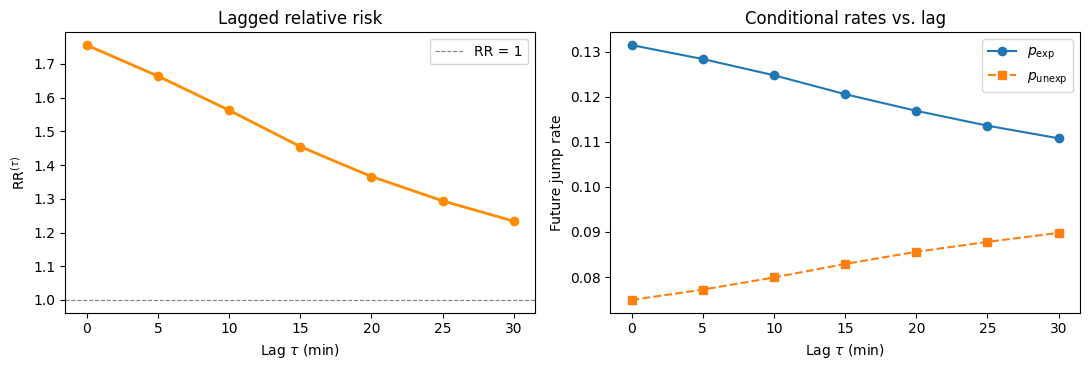

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# Left: RR vs lag
axes[0].plot(df_lag['τ (min)'], df_lag['RR'], 'o-', color='darkorange', lw=2)
axes[0].axhline(1, color='grey', ls='--', lw=0.8, label='RR = 1')
axes[0].set_xlabel('Lag $\\tau$ (min)')
axes[0].set_ylabel('$\\mathrm{RR}^{(\\tau)}$')
axes[0].set_title('Lagged relative risk')
axes[0].legend()

# Right: conditional rates vs lag
axes[1].plot(df_lag['τ (min)'], df_lag['p_exp'],   'o-', label='$p_\\mathrm{exp}$')
axes[1].plot(df_lag['τ (min)'], df_lag['p_unexp'], 's--', label='$p_\\mathrm{unexp}$')
axes[1].set_xlabel('Lag $\\tau$ (min)')
axes[1].set_ylabel('Future jump rate')
axes[1].set_title('Conditional rates vs. lag')
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
tau_star = df_lag['RR'].idxmax()
print(f"Peak RR at τ* = {tau_star} frames = {tau_star * 5} min")
print(f"RR(τ=0) = {df_lag.loc[0, 'RR']:.4f}  (original estimator)")
print(f"RR(τ=1) = {df_lag.loc[1, 'RR']:.4f}  (first lagged version)")

# ── YOUR INTERPRETATION ──────────────────────────────────────────────────────
# (a) What does τ* × 5 min suggest about the ERK relay timescale?
#The signal has no measurable propagation delay.

# (b) Does RR(τ) plateau or drop below 1 at large lags?
# RR(τ) does not plateau and does not drop below 1. It decreases monotonically with lag and stays above 1 for all tested τ.

# (c) Is the original RR(0) inflated or deflated relative to RR(1)?
# RR(0) is inflated relative to RR(1).


Peak RR at τ* = 0 frames = 0 min
RR(τ=0) = 1.7558  (original estimator)
RR(τ=1) = 1.6640  (first lagged version)


---
## ★ Task A2: Lagged Exposure Analysis Across Mutations
Czy różne mutacje wykazują odmienne czasowo-przestrzenne skale propagacji sygnału, tzn. jak szybko aktywacja propaguje się od komórki sąsiedniej do komórki centralnej?

Do analizy oprócz WT wybrano mutanty PIK3CA_H1047R oraz AKT1_E17K, ponieważ przy lagu $\tau = 0$ wykazywały one najbardziej kontrastujące poziomy koordynacji przestrzennej: odpowiednio najwyższy ($RR \approx 3.20$) oraz najniższy ($RR \approx 1.58$) Relative Risk aktywacji ERK (Part1_Block3_Comparison). 
Obie mutacje modyfikują dynamikę ERK pośrednio poprzez modyfikację szlaku PI3K/AKT: PIK3CA_H1047R działa na samym szczycie szlaku (upstream), zwiększając ekscytowalność sieci i promując masową propagację fal ERK, podczas gdy AKT1_E17K działa niżej (downstream), uruchamiając ujemne sprzężenia zwrotne, które wyciszają ERK i promują autonomię komórkową. Wprowadzenie opóźnienia czasowego $\tau = 0 \dots 6$ ramek (ramka 5 min) pozwala sprawdzić, w jakim stopniu te skrajne tryby regulacji wpływają na charakterystyczną skalę czasową odpowiedzi falowej ERK na bodźce od sąsiadów.

In [8]:
import json, sys, subprocess
SCRIPTS_DIR  = PROJECT_ROOT / 'scripts'
DATA_PATH    = PROJECT_ROOT / 'single-cell-tracks_exp1-6_noErbB2.csv.gz'
META_PATH    = PROJECT_ROOT / '01-readme-experiment-description_2022-04-05.csv'
SIGNAL_COL = 'ERKKTR_ratio'


In [9]:
def run_single_block(exp, site, signal, radius=60, window=3, quantile=0.9, outdir_tag=None):
    outdir = OUTPUT_ROOT / (outdir_tag or f'exp_{exp}_site_{site}_{signal}')
    # Reuse existing output if already computed with default tag
    summary_path = OUTPUT_ROOT / f'exp_{exp}_site_{site}_{signal}' / 'summary.json'
    if summary_path.exists() and outdir_tag is None:
        with open(summary_path) as f:
            return json.load(f)
    cmd = [
        sys.executable, str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),
        '--data-path', str(DATA_PATH), '--meta-path', str(META_PATH),
        '--exp-id', str(exp), '--site-id', str(site),
        '--signal-col', signal,
        '--spatial-radius', str(radius),
        '--future-window-frames', str(window),
        '--jump-quantile', str(quantile),
        '--output-dir', str(OUTPUT_ROOT),
    ]
    subprocess.run(cmd, capture_output=True)
    with open(summary_path) as f:
        return json.load(f)

In [31]:
print('Running site 13 (PIK3CA_H1047R) …', end=' ', flush=True)
s13 = run_single_block(1, 13, SIGNAL_COL)
print('done')

print('Running site 5 (AKT1_E17K) …', end=' ', flush=True)
s5 = run_single_block(1, 5, SIGNAL_COL)
print('done')

Running site 13 (PIK3CA_H1047R) … done
Running site 5 (AKT1_E17K) … done


In [32]:
WT_nodes = pd.read_csv(
    OUTPUT_ROOT / 'exp_1_site_1_ERKKTR_ratio' / 'nodes.csv.gz'
)

AKT1_E17K_nodes = pd.read_csv(
    OUTPUT_ROOT / 'exp_1_site_5_ERKKTR_ratio' / 'nodes.csv.gz'
)

PIK3CA_H1047R_nodes = pd.read_csv(
    OUTPUT_ROOT / 'exp_1_site_13_ERKKTR_ratio' / 'nodes.csv.gz'
)

In [33]:
def compute_lagged_rr(nodes, max_lag=6):

    nodes = nodes.sort_values(
        ['track_id', 'Image_Metadata_T']
    ).reset_index(drop=True)

    # lagged exposure columns
    for tau in range(1, max_lag + 1):
        nodes[f'lagged_exposure_{tau}'] = (
            nodes.groupby('track_id')['neighbor_jump_now']
                 .shift(tau)
                 .fillna(False)
                 .astype(bool)
        )

    results = []

    for tau in range(max_lag + 1):

        col = (
            'neighbor_jump_now'
            if tau == 0
            else f'lagged_exposure_{tau}'
        )

        exposed = nodes[nodes[col] == True]
        unexposed = nodes[nodes[col] == False]

        p_exp = exposed['future_self_jump'].mean()
        p_unexp = unexposed['future_self_jump'].mean()

        rr = p_exp / p_unexp if p_unexp > 0 else np.nan

        results.append({
            'τ (frames)': tau,
            'τ (min)': tau * 5,
            'RR': round(rr, 4),
        })

    df_lag = pd.DataFrame(results).set_index('τ (frames)')

    return df_lag

In [34]:
df_wt = compute_lagged_rr(WT_nodes)
df_akt = compute_lagged_rr(AKT1_E17K_nodes)
df_pik3ca_h1047r = compute_lagged_rr(PIK3CA_H1047R_nodes)

C:\Users\gozma\AppData\Local\Temp\ipykernel_22944\2490268176.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
C:\Users\gozma\AppData\Local\Temp\ipykernel_22944\2490268176.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
C:\Users\gozma\AppData\Local\Temp\ipykernel_22944\2490268176.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.n

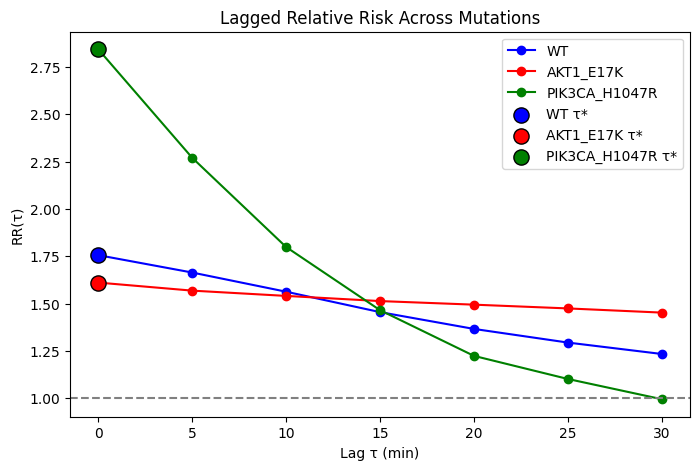

In [36]:
def add_tau_star_marker(df, label, color):

    idx = df['RR'].idxmax()

    tau_star = df.loc[idx, 'τ (min)']
    rr_star  = df.loc[idx, 'RR']

    plt.scatter(
        tau_star,
        rr_star,
        s=120,
        color=color,
        edgecolor='black',
        zorder=5,
        label=f'{label} τ*'
    )

plt.figure(figsize=(8,5))

# lines
plt.plot(df_wt['τ (min)'], df_wt['RR'],
         'o-', label='WT', color='blue')

plt.plot(df_akt['τ (min)'], df_akt['RR'],
         'o-', label='AKT1_E17K', color='red')

plt.plot(df_pik3ca_h1047r['τ (min)'], df_pik3ca_h1047r['RR'],
         'o-', label='PIK3CA_H1047R', color='green')

# τ* markers
add_tau_star_marker(df_wt, 'WT', 'blue')
add_tau_star_marker(df_akt, 'AKT1_E17K', 'red')
add_tau_star_marker(df_pik3ca_h1047r, 'PIK3CA_H1047R', 'green')

plt.axhline(1, color='gray', linestyle='--')

plt.xlabel('Lag τ (min)')
plt.ylabel('RR(τ)')
plt.title('Lagged Relative Risk Across Mutations')

plt.legend()
plt.show()

In [37]:
summary = pd.DataFrame({
    'mutation': ['WT', 'AKT1_E17K', 'PIK3CA_H1047R'],
    'tau_star': [
        df_wt.loc[df_wt['RR'].idxmax(), 'τ (min)'],
        df_akt.loc[df_akt['RR'].idxmax(), 'τ (min)'],
        df_pten.loc[df_pik3ca_h1047r['RR'].idxmax(), 'τ (min)'],
    ],
    'max_RR': [
        df_wt['RR'].max(),
        df_akt['RR'].max(),
        df_pik3ca_h1047r['RR'].max(),
    ]
})

summary

,mutation,tau_star,max_RR
0,WT,0,1.7558
1,AKT1_E17K,0,1.6109
2,PIK3CA_H1047R,0,2.8435


---
## Interpretacja
Analiza potwierdza, że mutacja PIK3CA_H1047R drastycznie wzmacnia czasowo-przestrzenną koordynację ERK ($RR \approx 2.85$). Efekt ten jest jednak silnie skupiony w czasie – gwałtowny spadek do wartości $1.0$ przy 30 minutach sugeruje, że po przejściu intensywnej fali aktywacji następuje natychmiastowe wygaszenie sygnału. 

W przeciwieństwie do niej, profil AKT1_E17K jest niemal płaski i stabilizuje się na poziomie $1.5$. Oznacza to promowanie autonomii komórkowej i odcięcie od dynamicznych fal sąsiadów; RR utrzymujące się powyżej 1 (≈1.5) dla AKT1_E17K wskazuje, że aktywacja sąsiadów nadal zwiększa prawdopodobieństwo skoku ERK, jednak efekt ten nie zanika ani nie tworzy wyraźnej struktury czasowej, co sugeruje raczej podwyższoną globalną aktywność niż właściwą propagację sygnału międzykomórkowego.

Wild Type (WT) stanowi fizjologiczną kontrolę: wykazuje wyraźną zależność od czasu (łagodniejsze nachylenie), jednak przy 30 minutach nie spada do jedności ($RR \approx 1.25$). Dowodzi to, że naturalna sygnalizacja w WT jest bardziej rozciągnięta w czasie, podczas gdy mutacja PIK3CA_H1047R patologicznie kondensuje i skraca czas trwania sprzężenia międzykomórkowego. Wszystkie linie osiągają maksimum przy $\tau^* = 0$, co wskazuje, że mechanizm inicjacji przekaźnictwa zachodzi szybciej niż interwał próbkowania (5 min).